In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

In [3]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [4]:
sentences = [
    ["我", "今天", "想", "去", "图书馆", "学习"],
    ["我", "今天", "想", "去", "食堂", "吃饭"],
    ["你", "今天", "想", "去", "操场", "跑步"],
    ["他", "明天", "想", "去", "图书馆", "看书"],
    ["我们", "明天", "想", "去", "教室", "上课"],
    ["机器学习", "可以", "帮助", "计算机", "从", "数据", "中", "学习"],
    ["深度学习", "可以", "处理", "图像", "文本", "语音"]
]

sentences

[['我', '今天', '想', '去', '图书馆', '学习'],
 ['我', '今天', '想', '去', '食堂', '吃饭'],
 ['你', '今天', '想', '去', '操场', '跑步'],
 ['他', '明天', '想', '去', '图书馆', '看书'],
 ['我们', '明天', '想', '去', '教室', '上课'],
 ['机器学习', '可以', '帮助', '计算机', '从', '数据', '中', '学习'],
 ['深度学习', '可以', '处理', '图像', '文本', '语音']]

In [5]:
PAD = "[PAD]"
MASK = "[MASK]"
UNK = "[UNK]"

special_tokens = [PAD, MASK, UNK]

all_tokens = sorted(set(token for sent in sentences for token in sent))

vocab = special_tokens + all_tokens

word2id = {word: idx for idx, word in enumerate(vocab)}
id2word = {idx: word for word, idx in word2id.items()}

pad_id = word2id[PAD]
mask_id = word2id[MASK]
unk_id = word2id[UNK]

max_len = max(len(sent) for sent in sentences)

print("词表大小：", len(vocab))
print("最大句子长度：", max_len)
print("词表：")
print(vocab)

词表大小： 32
最大句子长度： 8
词表：
['[PAD]', '[MASK]', '[UNK]', '上课', '中', '今天', '从', '他', '你', '去', '可以', '吃饭', '图书馆', '图像', '处理', '学习', '帮助', '想', '我', '我们', '操场', '教室', '数据', '文本', '明天', '机器学习', '深度学习', '看书', '计算机', '语音', '跑步', '食堂']


In [6]:
def encode(tokens):
    """
    把 token 列表转换成 id 列表
    """
    return [word2id.get(token, unk_id) for token in tokens]


def decode(ids):
    """
    把 id 列表转换回 token 列表
    """
    return [id2word.get(idx, UNK) for idx in ids]


def pad_ids(ids, max_len=max_len):
    """
    把不同长度的句子补齐到相同长度
    """
    ids = ids[:max_len]
    return ids + [pad_id] * (max_len - len(ids))

In [7]:
example = ["我", "今天", "想", "去", "图书馆", "学习"]

ids = encode(example)
padded_ids = pad_ids(ids)

print("原始 token：", example)
print("编码结果：", ids)
print("补齐结果：", padded_ids)
print("解码结果：", decode(padded_ids))

原始 token： ['我', '今天', '想', '去', '图书馆', '学习']
编码结果： [18, 5, 17, 9, 12, 15]
补齐结果： [18, 5, 17, 9, 12, 15, 0, 0]
解码结果： ['我', '今天', '想', '去', '图书馆', '学习', '[PAD]', '[PAD]']


In [8]:
gpt_samples = []

for sent in sentences:
    for i in range(1, len(sent)):
        prefix = sent[:i]
        target = sent[i]
        gpt_samples.append((prefix, target))

gpt_df = pd.DataFrame({
    "输入 prefix": [" ".join(sample[0]) for sample in gpt_samples],
    "预测目标 next token": [sample[1] for sample in gpt_samples]
})

gpt_df.head(15)

,输入 prefix,预测目标 next token
0,我,今天
1,我 今天,想
2,我 今天 想,去
3,我 今天 想 去,图书馆
4,我 今天 想 去 图书馆,学习
5,我,今天
6,我 今天,想
7,我 今天 想,去
8,我 今天 想 去,食堂
9,我 今天 想 去 食堂,吃饭


In [9]:
seq_len = 6

causal_mask = torch.tril(torch.ones(seq_len, seq_len))

causal_mask

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])

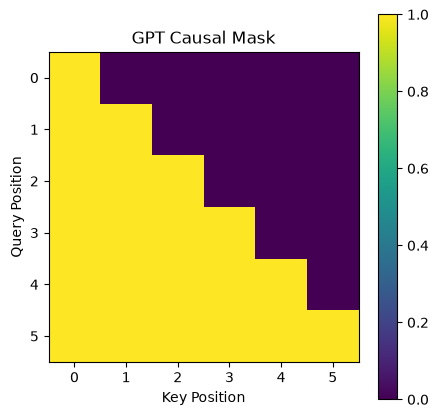

In [10]:
plt.figure(figsize=(5, 5))
plt.imshow(causal_mask)
plt.title("GPT Causal Mask")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.xticks(range(seq_len))
plt.yticks(range(seq_len))
plt.colorbar()
plt.show()

In [11]:
X_gpt = []
y_gpt = []

for prefix, target in gpt_samples:
    prefix_ids = encode(prefix)
    target_id = word2id[target]
    
    X_gpt.append(pad_ids(prefix_ids))
    y_gpt.append(target_id)

X_gpt = torch.tensor(X_gpt, dtype=torch.long)
y_gpt = torch.tensor(y_gpt, dtype=torch.long)

print("X_gpt shape:", X_gpt.shape)
print("y_gpt shape:", y_gpt.shape)

X_gpt shape: torch.Size([37, 8])
y_gpt shape: torch.Size([37])


In [12]:
class ToyGPTLikeModel(nn.Module):
    """
    极简 GPT-like 模型
    
    这个模型做的事情：
    1. 把 token id 变成 embedding
    2. 对 prefix 的 embedding 求平均
    3. 用 Linear 层预测下一个 token
    
    注意：
    这不是真正的 GPT。
    它只是帮助我们理解 GPT 的训练目标。
    """
    
    def __init__(self, vocab_size, embed_dim, pad_id):
        super().__init__()
        
        self.pad_id = pad_id
        
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_id
        )
        
        self.fc = nn.Linear(embed_dim, vocab_size)
    
    def forward(self, x):
        emb = self.embedding(x)
        
        mask = (x != self.pad_id).unsqueeze(-1)
        emb = emb * mask
        
        avg_emb = emb.sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        
        logits = self.fc(avg_emb)
        
        return logits

In [13]:
vocab_size = len(vocab)
embed_dim = 16

gpt_like_model = ToyGPTLikeModel(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    pad_id=pad_id
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(gpt_like_model.parameters(), lr=0.05)

gpt_like_model

ToyGPTLikeModel(
  (embedding): Embedding(32, 16, padding_idx=0)
  (fc): Linear(in_features=16, out_features=32, bias=True)
)

In [14]:
epochs = 100

for epoch in range(1, epochs + 1):
    gpt_like_model.train()
    
    logits = gpt_like_model(X_gpt)
    loss = criterion(logits, y_gpt)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        preds = logits.argmax(dim=1)
        acc = (preds == y_gpt).float().mean().item()
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Acc: {acc:.4f}")

Epoch  20 | Loss: 0.3668 | Acc: 0.9730
Epoch  40 | Loss: 0.0707 | Acc: 0.9730
Epoch  60 | Loss: 0.0459 | Acc: 0.9730
Epoch  80 | Loss: 0.0422 | Acc: 0.9730
Epoch 100 | Loss: 0.0409 | Acc: 0.9730


In [15]:
def predict_next_token(prefix_tokens, top_k=5):
    gpt_like_model.eval()
    
    ids = encode(prefix_tokens)
    x = torch.tensor([pad_ids(ids)], dtype=torch.long)
    
    with torch.no_grad():
        logits = gpt_like_model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0)
    
    top_probs, top_ids = torch.topk(probs, k=top_k)
    
    result = pd.DataFrame({
        "候选 token": [id2word[idx.item()] for idx in top_ids],
        "概率": [round(prob.item(), 4) for prob in top_probs]
    })
    
    return result

In [16]:
predict_next_token(["我", "今天", "想", "去"])

,候选 token,概率
0,食堂,0.4976
1,图书馆,0.4973
2,操场,0.0019
3,吃饭,0.0011
4,学习,0.0008


In [17]:
predict_next_token(["机器学习", "可以", "帮助"])

,候选 token,概率
0,计算机,0.9967
1,从,0.0016
2,数据,0.0010
3,帮助,0.0006
4,可以,0.0000


In [18]:
mlm_samples = []

for sent in sentences:
    for pos in range(len(sent)):
        masked_sent = sent.copy()
        target = masked_sent[pos]
        masked_sent[pos] = MASK
        
        mlm_samples.append((masked_sent, target, pos))

mlm_df = pd.DataFrame({
    "BERT 输入": [" ".join(sample[0]) for sample in mlm_samples],
    "预测目标": [sample[1] for sample in mlm_samples],
    "mask 位置": [sample[2] for sample in mlm_samples]
})

mlm_df.head(15)

,BERT 输入,预测目标,mask 位置
0,[MASK] 今天 想 去 图书馆 学习,我,0
1,我 [MASK] 想 去 图书馆 学习,今天,1
2,我 今天 [MASK] 去 图书馆 学习,想,2
3,我 今天 想 [MASK] 图书馆 学习,去,3
4,我 今天 想 去 [MASK] 学习,图书馆,4
5,我 今天 想 去 图书馆 [MASK],学习,5
6,[MASK] 今天 想 去 食堂 吃饭,我,0
7,我 [MASK] 想 去 食堂 吃饭,今天,1
8,我 今天 [MASK] 去 食堂 吃饭,想,2
9,我 今天 想 [MASK] 食堂 吃饭,去,3


In [19]:
seq_len = 6

bert_visible_matrix = torch.ones(seq_len, seq_len)

bert_visible_matrix

tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])

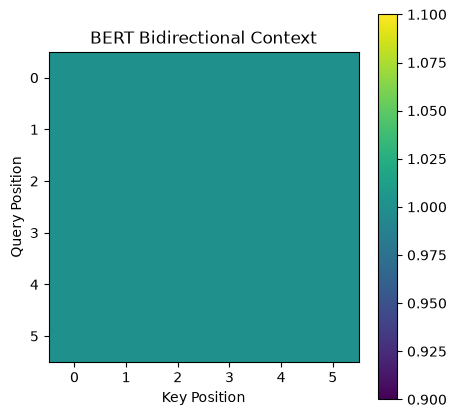

In [20]:
plt.figure(figsize=(5, 5))
plt.imshow(bert_visible_matrix)
plt.title("BERT Bidirectional Context")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.xticks(range(seq_len))
plt.yticks(range(seq_len))
plt.colorbar()
plt.show()

In [21]:
X_bert = []
y_bert = []

for masked_sent, target, pos in mlm_samples:
    input_ids = encode(masked_sent)
    target_id = word2id[target]
    
    X_bert.append(pad_ids(input_ids))
    y_bert.append(target_id)

X_bert = torch.tensor(X_bert, dtype=torch.long)
y_bert = torch.tensor(y_bert, dtype=torch.long)

print("X_bert shape:", X_bert.shape)
print("y_bert shape:", y_bert.shape)

X_bert shape: torch.Size([44, 8])
y_bert shape: torch.Size([44])


In [22]:
class ToyBERTLikeModel(nn.Module):
    """
    极简 BERT-like 模型
    
    这个模型做的事情：
    1. 输入一个带 [MASK] 的句子
    2. 把 token id 变成 embedding
    3. 对整句话的 embedding 求平均
    4. 预测被 mask 掉的 token
    
    注意：
    这不是真正的 BERT。
    它只是帮助我们理解 BERT 的 MLM 训练目标。
    """
    
    def __init__(self, vocab_size, embed_dim, pad_id):
        super().__init__()
        
        self.pad_id = pad_id
        
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_id
        )
        
        self.fc = nn.Linear(embed_dim, vocab_size)
    
    def forward(self, x):
        emb = self.embedding(x)
        
        mask = (x != self.pad_id).unsqueeze(-1)
        emb = emb * mask
        
        avg_emb = emb.sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        
        logits = self.fc(avg_emb)
        
        return logits

In [23]:
bert_like_model = ToyBERTLikeModel(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    pad_id=pad_id
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bert_like_model.parameters(), lr=0.05)

bert_like_model

ToyBERTLikeModel(
  (embedding): Embedding(32, 16, padding_idx=0)
  (fc): Linear(in_features=16, out_features=32, bias=True)
)

In [24]:
epochs = 100

for epoch in range(1, epochs + 1):
    bert_like_model.train()
    
    logits = bert_like_model(X_bert)
    loss = criterion(logits, y_bert)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        preds = logits.argmax(dim=1)
        acc = (preds == y_bert).float().mean().item()
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Acc: {acc:.4f}")

Epoch  20 | Loss: 1.0037 | Acc: 0.9545
Epoch  40 | Loss: 0.0818 | Acc: 1.0000
Epoch  60 | Loss: 0.0131 | Acc: 1.0000
Epoch  80 | Loss: 0.0067 | Acc: 1.0000
Epoch 100 | Loss: 0.0048 | Acc: 1.0000


In [25]:
def predict_mask_token(masked_tokens, top_k=5):
    if MASK not in masked_tokens:
        raise ValueError("输入句子中必须包含 [MASK]")
    
    bert_like_model.eval()
    
    ids = encode(masked_tokens)
    x = torch.tensor([pad_ids(ids)], dtype=torch.long)
    
    with torch.no_grad():
        logits = bert_like_model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0)
    
    top_probs, top_ids = torch.topk(probs, k=top_k)
    
    result = pd.DataFrame({
        "候选 token": [id2word[idx.item()] for idx in top_ids],
        "概率": [round(prob.item(), 4) for prob in top_probs]
    })
    
    return result

In [26]:
predict_mask_token(["我", "今天", "想", "去", MASK, "学习"])

,候选 token,概率
0,图书馆,0.9953
1,吃饭,0.0020
2,跑步,0.0009
3,食堂,0.0007
4,我,0.0005


In [27]:
predict_mask_token(["机器学习", "可以", "帮助", MASK, "从", "数据", "中", "学习"])

,候选 token,概率
0,计算机,0.9949
1,可以,0.0012
2,从,0.0008
3,今天,0.0008
4,中,0.0007


In [28]:
compare_df = pd.DataFrame({
    "模型": ["GPT-like", "BERT-like"],
    "输入示例": [
        "我 今天 想 去",
        "我 今天 想 去 [MASK] 学习"
    ],
    "输出目标": [
        "图书馆",
        "图书馆"
    ],
    "训练思想": [
        "根据前文预测下一个 token",
        "根据上下文预测被遮住的 token"
    ],
    "更擅长": [
        "生成",
        "理解"
    ]
})

compare_df

,模型,输入示例,输出目标,训练思想,更擅长
0,GPT-like,我 今天 想 去,图书馆,根据前文预测下一个 token,生成
1,BERT-like,我 今天 想 去 [MASK] 学习,图书馆,根据上下文预测被遮住的 token,理解
